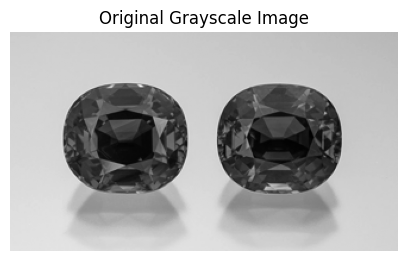

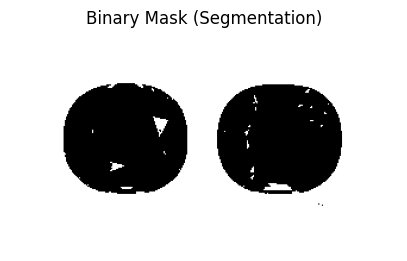

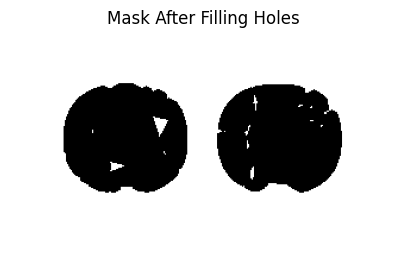

Number of detected sapphires: 2
Sapphire 1: Area = 7764 pixels
Sapphire 2: Area = 7738 pixels


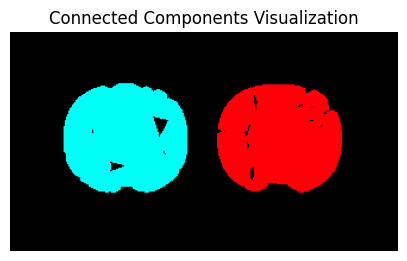

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def process_sapphires_image(filename):
    img = cv2.imread(filename)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


    plt.figure(figsize=(5,5))
    plt.title("Original Grayscale Image")
    plt.imshow(img_gray, cmap='gray')
    plt.axis('off')
    plt.show()


    _, mask = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    plt.figure(figsize=(5,5))
    plt.title("Binary Mask (Segmentation)")
    plt.imshow(mask, cmap='gray')
    plt.axis('off')
    plt.show()


    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask_filled = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    plt.figure(figsize=(5,5))
    plt.title("Mask After Filling Holes")
    plt.imshow(mask_filled, cmap='gray')
    plt.axis('off')
    plt.show()

    binary = cv2.bitwise_not(mask_filled)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

    print(f"Number of detected sapphires: {num_labels - 1}")
    for i in range(1, num_labels):
        print(f"Sapphire {i}: Area = {stats[i, cv2.CC_STAT_AREA]} pixels")

    label_hue = np.uint8(179*labels/np.max(labels))
    blank_ch = 255*np.ones_like(label_hue)
    labeled_img = cv2.merge([label_hue, blank_ch, blank_ch])
    labeled_img = cv2.cvtColor(labeled_img, cv2.COLOR_HSV2RGB)
    labeled_img[label_hue==0] = 0

    plt.figure(figsize=(5,5))
    plt.title("Connected Components Visualization")
    plt.imshow(labeled_img)
    plt.axis('off')
    plt.show()

process_sapphires_image('/content/sample_data/sapphires.png')
